### MNIST Digit Generator - Diffusion Model
---


### Overview of the Generator pipeline
In this notebook, MNIST digit generator is developed by using the Diffusion model. Here are the key steps taken in this notebook in this process.

---

1. **Imports**



---


2. **Set Hyperparameters for the Network:** Its section is usually completed and continously updated until the optimised network is attained.



---



3. **Dataset Loader and Visulaizing the original digit images**: Create dataset for the network training. The dataset consitutes of training images only. No validation set was established as for Generator, the goal is to make network capable of generating new images. Hence, there is no profound role validation or test sets can make for current goals of network. For evaluating performance of Genertor, there are other methods that give more useful insights. They will be discussed below.
Moreover, the real images were visulaized for human reference.



---



4. **Use of " denoising_diffusion_pytorch":** The `denoising_diffusion_pytorch ` library has been used in this network. It is a powerful tool that significantly simplifies the implementation of Denoising Diffusion Probabilistic Models (DDPMs). It provides a clean and modular framework for building and training diffusion models, abstracting away much of the complex mathematical details.
Here are instances where this library had been used.

 `Imports section`: This cell imports the `Unet` and `GaussianDiffusion` classes, making them available for use.

 `Build DDPM section`: Here, the `Unet` model is initialized and then wrapped by `GaussianDiffusion` to set up the complete diffusion model for training. This is where the core DDPM architecture is instantiated.

`Helper function **generate_from_checkpoint** `: This function, designed to generate images from saved model checkpoints, re-instantiates `Unet` and `GaussianDiffusion` to load and use the trained models. This function is later used in the "Comparison over different epochs" section.

`Reverse Diffusion Progression section`: Similar to checkpoint loading, this cell loads a trained `Unet` model and wraps it with `GaussianDiffusion` specifically for visualizing the reverse diffusion process.

`Comparison of FID at each checkpoint section`: In this cell, for each epoch's checkpoint, `Unet` and `GaussianDiffusion` are initialized and loaded to generate images necessary for FID score calculation

---

5. **Forward Diffusion Pass:**  

- A noise schedule (`betas`, `alphas`, `alpha_bars`) is created to control the
amount of noise added at each timestep.
- A `forward_diffusion_sample` function is defined to simulate the forward diffusion process, adding Gaussian noise to an image over `TIME_STEPS` to gradually turn it into pure noise.
- This process is then visualized, showing how digits degrade into noise over increasing timesteps, and a GIF shows the continuous process.

---

6. **Model Architecture and Training:**

The core of the generative model is a `Unet` (noise predictor) from the `denoising_diffusion_pytorch` library. This Unet is responsible for learning to predict the noise added at each step.

The Unet model is wrapped by `GaussianDiffusion` (also from denoising_diffusion_pytorch), which handles the forward and reverse diffusion mechanics. This library significantly simplifies the implementation of DDPMs.
The model is trained over N_EPOCHS using an AdamW optimizer. The training loop calculates the loss (difference between predicted and actual noise), performs backpropagation, and updates model parameters. Checkpoints are saved periodically.
The training loss curve is plotted at the end, showing its decreasing trend.

---

7. **Image Generation and Evaluation:**

**Generated Samples:** The trained diffusion model is used to generate new MNIST digits from pure noise, demonstrating its generative capabilities. These generated digits are visualized.

**Reverse Diffusion Visualization:** The reverse (denoising) process is also visualized step-by-step, showing how a random noise image is gradually transformed into a recognizable digit.

**FID (Fréchet Inception Distance) Evaluation:** To quantitatively assess the quality of generated images, the FID score is calculated. This involves:
Saving a set of real MNIST images.

---

8. **Loading checkpoints from different training epochs.**
For each checkpoint,  a specified number of images (e.g., 1000)are generated and saved them into folders.

Images generated by all five checkpoints are visualized and compared in grid plot.

Using the pytorch-fid library, the FID is calculated between the generated images and the real images for all checkpoint_epochs_generated images.

The FID scores are analyzed, showing that the model achieves a good FID (around 15.26 at epoch 30), indicating high-quality image generation. A plot of FID vs. Training Epoch demonstrates how the generative quality improves over time, often converging before the final epoch.


---

9. **Conclusions**:

---

10. **Ways to Improve the Model´s Performance**

---



### **1. Initial Steps**

### Imports

In [ ]:
pip install denoising_diffusion_pytorch

In [ ]:
import os
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import torchvision

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import torchvision.datasets as datasets
from torchvision import transforms

from denoising_diffusion_pytorch import (
    Unet,
    GaussianDiffusion
)

### Hyperparameters

In [ ]:
LEARNING_RATE = 4e-4
BATCH_SIZE = 128

N_EPOCHS = 50

IMAGE_SIZE = 28

TIME_STEPS = 1000
SAMPLING_TIMESTEPS = 250

DIM = 32
DIM_MULTS = (1, 2, 4)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [ ]:
def generate_from_checkpoint(
    checkpoint_path,
    batch_size=16
):

    model = Unet(
        dim=DIM,
        dim_mults=DIM_MULTS,
        channels=1,
        flash_attn=False
    )

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device
        )
    )

    model = model.to(device)

    diffusion = GaussianDiffusion(
        model,
        image_size=IMAGE_SIZE,
        timesteps=TIME_STEPS,
        sampling_timesteps=SAMPLING_TIMESTEPS
    ).to(device)

    model.eval()

    with torch.no_grad():

        samples = diffusion.sample(
            batch_size=batch_size
        )

    return samples.cpu()

### Dataset

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = datasets.MNIST(
    root="dataset/",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

### Visualize Original Digits

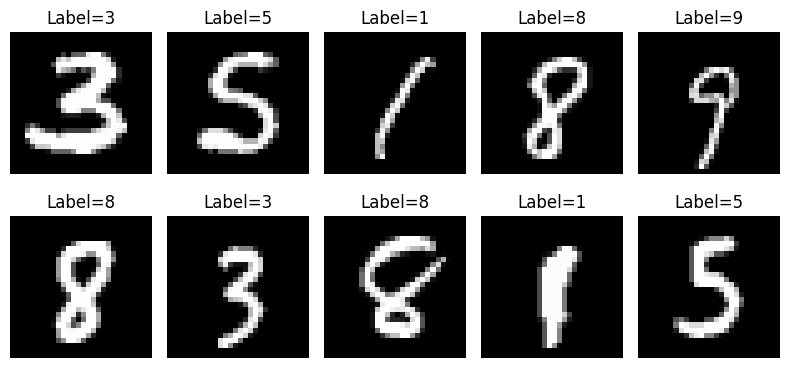

In [ ]:
images, labels = next(iter(loader))

fig, axes = plt.subplots(
    2,
    5,
    figsize=(8,4)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        images[i,0],
        cmap="gray"
    )

    ax.set_title(
        f"Label={labels[i]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

### **2. Forward Diffusion Pass**

### Step 1: Preparing a Generator - Learning the noise schedule

### Create Noise Schedule
For forward diffusion pass

In [ ]:
betas = torch.linspace(
    1e-4,
    0.02,
    TIME_STEPS
)

alphas = 1.0 - betas

alpha_bars = torch.cumprod(
    alphas,
    dim=0
)


### Forward Diffusion Function

This is the mathematical DDPM forward process:

In [ ]:
def forward_diffusion_sample(
    x0,
    t
):

    noise = torch.randn_like(x0)

    alpha_bar_t = alpha_bars[t]

    xt = (
        torch.sqrt(alpha_bar_t) * x0
        +
        torch.sqrt(
            1 - alpha_bar_t
        ) * noise
    )

    return xt

### Forward Diffusion Visualization

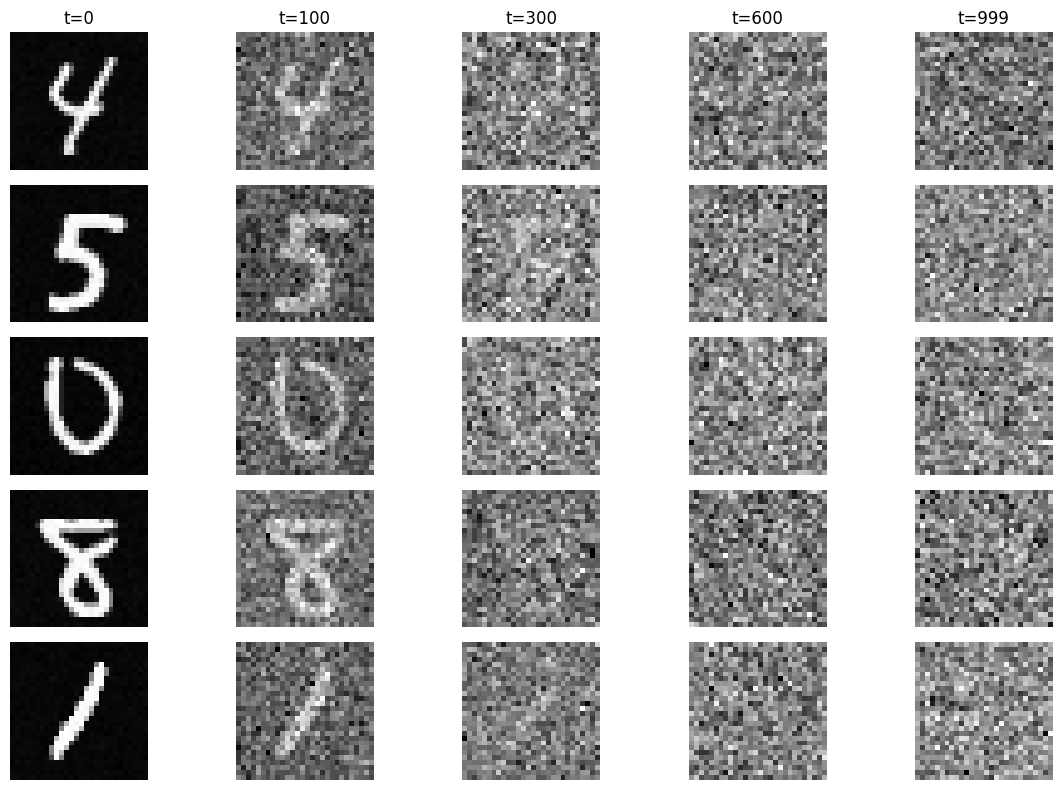

In [ ]:
images, _ = next(iter(loader))

x0 = images[:5]

steps = [
    0,
    100,
    300,
    600,
    999
]

fig, axes = plt.subplots(
    5,
    len(steps),
    figsize=(12,8)
)

for row in range(5):

    for col, t in enumerate(steps):

        xt = forward_diffusion_sample(
            x0[row:row+1],
            t
        )

        axes[row,col].imshow(
            xt[0,0],
            cmap="gray"
        )

        axes[row,col].axis("off")

        if row == 0:
            axes[row,col].set_title(
                f"t={t}"
            )

plt.tight_layout()
plt.show()

### Forward Diffusion GIF

Saved: forward_diffusion.gif


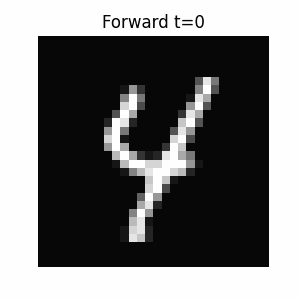

In [ ]:
import os
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from IPython.display import Image

os.makedirs(
    "forward_frames",
    exist_ok=True
)

digit = x0[0:1]

filenames = []

steps = range(
    0,
    TIME_STEPS,
    20
)

for t in steps:

    xt = forward_diffusion_sample(
        digit,
        t
    )

    plt.figure(figsize=(3,3))

    plt.imshow(
        xt[0,0],
        cmap="gray"
    )

    plt.title(
        f"Forward t={t}"
    )

    plt.axis("off")

    filename = (
        f"forward_frames/frame_{t}.png"
    )

    plt.savefig(filename)

    plt.close()

    filenames.append(filename)

gif_path = "forward_diffusion.gif"

with imageio.get_writer(
    gif_path,
    mode="I",
    duration=0.15
) as writer:

    for filename in filenames:

        image = imageio.imread(
            filename
        )

        writer.append_data(image)

print(
    "Saved:",
    gif_path
)

# Display GIF in notebook
display(Image(open(gif_path,'rb').read()))

### **3. Training the model**

### Build DDPM

In [ ]:
# Initialize the U-Net model, which acts as the noise predictor in DDPM
model = Unet(
    dim=DIM,  # Base dimension for the U-Net model
    dim_mults=DIM_MULTS,  # Multipliers for U-Net dimensions at different resolutions
    channels=1,  # Number of input channels (1 for grayscale MNIST images)
    flash_attn=False  # Disables FlashAttention for broader compatibility
)

# Wrap the U-Net model with GaussianDiffusion to handle the diffusion process
diffusion = GaussianDiffusion(
    model,  # The noise prediction model (U-Net)
    image_size=IMAGE_SIZE,  # Size of the input images (e.g., 28x28 for MNIST)
    timesteps=TIME_STEPS,  # Total number of diffusion timesteps
    sampling_timesteps=SAMPLING_TIMESTEPS  # Number of timesteps used during sampling (can be fewer than total)
)

# Move both the U-Net model and the diffusion wrapper to the specified device (CPU or GPU)
model = model.to(device)
diffusion = diffusion.to(device)

# Initialize the AdamW optimizer for training the U-Net model
optimizer = torch.optim.AdamW(
    model.parameters(),  # Parameters of the U-Net model to optimize
    lr=LEARNING_RATE  # Learning rate for the optimizer
)

### Training loop

In [ ]:
# List to store the loss history for plotting later
loss_history = []

# Loop through each epoch for training
for epoch in range(N_EPOCHS):

    # Initialize running loss for the current epoch
    running_loss = 0

    # Iterate over batches from the DataLoader
    for images, _ in loader:

        # Move images to the specified device (GPU/CPU)
        images = images.to(device)

        # Zero out gradients from the previous iteration
        optimizer.zero_grad()

        # Calculate the loss for the current batch (forward pass)
        # The diffusion model handles adding noise and predicting it
        loss = diffusion(images)

        # Perform backpropagation to compute gradients
        loss.backward()

        # Update model parameters using the optimizer
        optimizer.step()

        # Accumulate the loss for the current epoch
        running_loss += loss.item()

    # Calculate the average loss for the current epoch
    epoch_loss = running_loss / len(loader)

    # Store the epoch loss in the history list
    loss_history.append(epoch_loss)

    # Print the epoch number and loss
    print(
        f"Epoch {epoch+1}/{N_EPOCHS}"
        f" Loss={epoch_loss:.5f}"
    )

    # Save a model checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:

        # Save the model's state dictionary
        torch.save(
            model.state_dict(),
            f"mnist_diffusion_epoch_{epoch+1}.pth"
        )

        # Confirm checkpoint saving
        print(
            f"Checkpoint saved at epoch {epoch+1}"
        )


Epoch 1/50 Loss=0.09290
Epoch 2/50 Loss=0.04892
Epoch 3/50 Loss=0.04433
Epoch 4/50 Loss=0.04198
Epoch 5/50 Loss=0.04051
Epoch 6/50 Loss=0.04038
Epoch 7/50 Loss=0.03911
Epoch 8/50 Loss=0.03924
Epoch 9/50 Loss=0.03851
Epoch 10/50 Loss=0.03789
Checkpoint saved at epoch 10
Epoch 11/50 Loss=0.03797
Epoch 12/50 Loss=0.03812
Epoch 13/50 Loss=0.03740
Epoch 14/50 Loss=0.03747
Epoch 15/50 Loss=0.03750
Epoch 16/50 Loss=0.03706
Epoch 17/50 Loss=0.03702
Epoch 18/50 Loss=0.03664
Epoch 19/50 Loss=0.03701
Epoch 20/50 Loss=0.03647
Checkpoint saved at epoch 20
Epoch 21/50 Loss=0.03649
Epoch 22/50 Loss=0.03627
Epoch 23/50 Loss=0.03630
Epoch 24/50 Loss=0.03646
Epoch 25/50 Loss=0.03639
Epoch 26/50 Loss=0.03618
Epoch 27/50 Loss=0.03622
Epoch 28/50 Loss=0.03594
Epoch 29/50 Loss=0.03585
Epoch 30/50 Loss=0.03596
Checkpoint saved at epoch 30
Epoch 31/50 Loss=0.03577
Epoch 32/50 Loss=0.03577
Epoch 33/50 Loss=0.03573
Epoch 34/50 Loss=0.03553
Epoch 35/50 Loss=0.03559
Epoch 36/50 Loss=0.03564
Epoch 37/50 Loss=0.035

### Training Loss curve

In [ ]:
torch.save(
    model.state_dict(),
    "mnist_diffusion_model.pth"
)

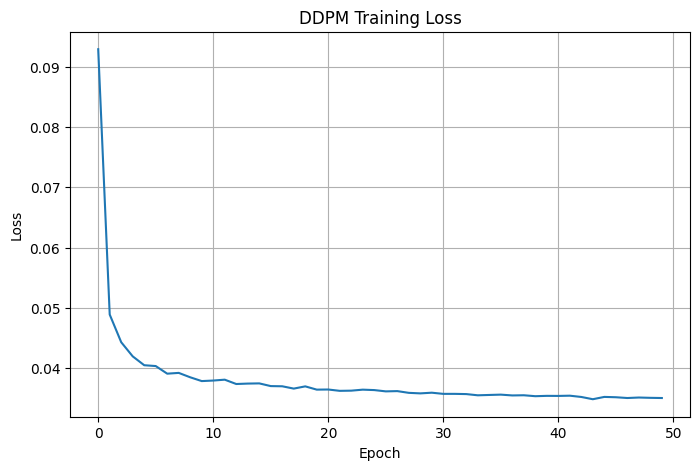

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "DDPM Training Loss"
)

plt.grid()

plt.show()

The decreasing training loss behaviour is trivial. To evaluate the performance of a generator, loss curves arent best choices. FID scores can help see how well the generator performed.


Although the training loss provides useful information about the optimization process, it is not necessarily the best indicator of the quality of a generative model. In a diffusion model, the loss measures how accurately the network predicts the noise added during the forward diffusion process. A lower loss indicates that the model has become better at the denoising task used during training, but it does not directly measure the realism, diversity, or overall quality of the images generated during sampling. It is therefore possible for two models to have similar training losses while producing noticeably different visual results. For generative models, the ultimate objective is not merely to minimize prediction error but to generate samples that closely resemble the true data distribution.

### **4. Digits Generation**

### Generate Digits using the epoch 50 Model

In [ ]:
with torch.no_grad():

    samples = diffusion.sample(
        batch_size=16
    )

samples = samples.cpu()

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

### Generated Digits Grid

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

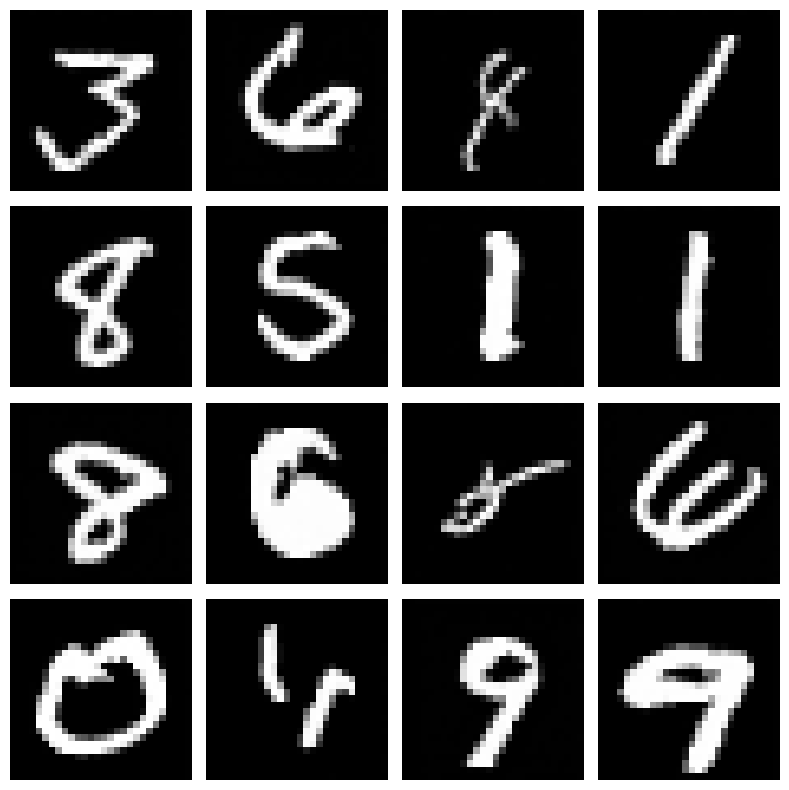

In [ ]:
with torch.no_grad():

    generated_digits = diffusion.sample(
        batch_size=16
    )

fig, axes = plt.subplots(
    4,
    4,
    figsize=(8,8)
)

for i, ax in enumerate(
    axes.flat
):

    ax.imshow(
        generated_digits[i,0]
            .cpu(),
        cmap="gray"
    )

    ax.axis("off")

plt.tight_layout()

plt.show()

### Generate more digits

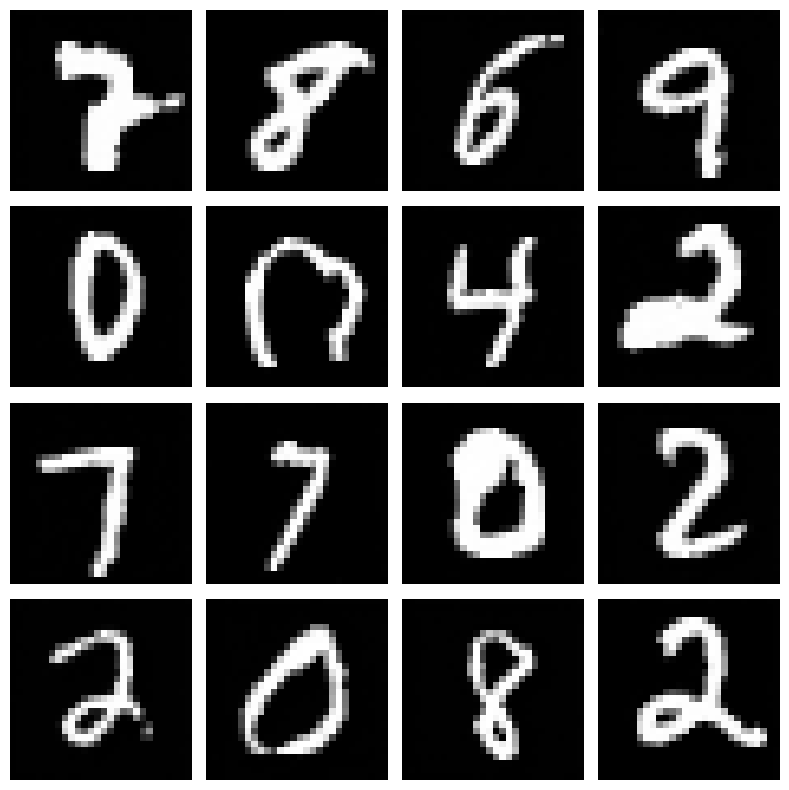

In [ ]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(8,8)
)

for i, ax in enumerate(
    axes.flat
):

    ax.imshow(
        samples[i,0],
        cmap="gray"
    )

    ax.axis("off")

plt.tight_layout()

plt.show()

It can be seen that the model generated fairly recognizable digits. Only digit in (row 2, column 2) is vague and unrecognizable. Moreover, the visual quality isnt great as compared to real images. However, the difference isnt huge either. We can also see in this generated sample specifically, there is variety in ways a digit is written. For example, all 2 digits here are written differently. However, its also worth noticing that there are more 2´s in this sample than any other number. It is possible for a network to generate again and again same sets of digits, without diversity and fooling the optimiser due to good generation of digits. It can be a sign of overfitting for Generators. Diversity, frequency and uniqueness also matters for Generator´s performance and quality. To check this, two additonal methods are used. Firstly, the Generator after every ten epochs was saved upto 50 epochs. And 1000 images were generated using all five generators. Then,  
1.  5 random images from each model was visulaized in grid plot, for human inspection and compare the visual quality
2. FID score is calculated for each generator, the output more closely reflects the quality of a Generator. More details are discussed in the intented section for this figure of metric.


Before that, lets see how reverse diffusion process works!


### Reverse Diffusion Progression

### Load the trained diffusion model for MNIST

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = Unet(
    dim=DIM,
    dim_mults=DIM_MULTS,
    channels=1,
    flash_attn=False
)

model.load_state_dict(
    torch.load(
        "mnist_diffusion_model.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

diffusion = GaussianDiffusion(
    model,
    image_size=IMAGE_SIZE,
    timesteps=TIME_STEPS,
    sampling_timesteps=SAMPLING_TIMESTEPS
).to(device)

### Start from pure guasian noise

In [ ]:
import torch

x = torch.randn(
    1,
    1,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=device
)

print(x.shape)

torch.Size([1, 1, 28, 28])


### Reverse Diffusion with snapshots

In [ ]:
import os

os.makedirs(
    "reverse_frames",
    exist_ok=True
)

snapshots = []

snapshot_timesteps = [
    999,
    900,
    800,
    700,
    600,
    500,
    400,
    300,
    200,
    100,
    50,
    0
]

### Reverse Loop

In [ ]:
with torch.no_grad():

    x = torch.randn(
        1,
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=device
    )

    for t in reversed(range(TIME_STEPS)):

        x, _ = diffusion.p_sample(
            x,
            t
        )

        if t in snapshot_timesteps:

            snapshots.append(
                (
                    t,
                    x.detach()
                     .cpu()
                     .clone()
                )
            )

            print(
                f"Saved snapshot at t={t}"
            )

Saved snapshot at t=999
Saved snapshot at t=900
Saved snapshot at t=800
Saved snapshot at t=700
Saved snapshot at t=600
Saved snapshot at t=500
Saved snapshot at t=400
Saved snapshot at t=300
Saved snapshot at t=200
Saved snapshot at t=100
Saved snapshot at t=50
Saved snapshot at t=0


### Plots of Reverse Diffusion pass

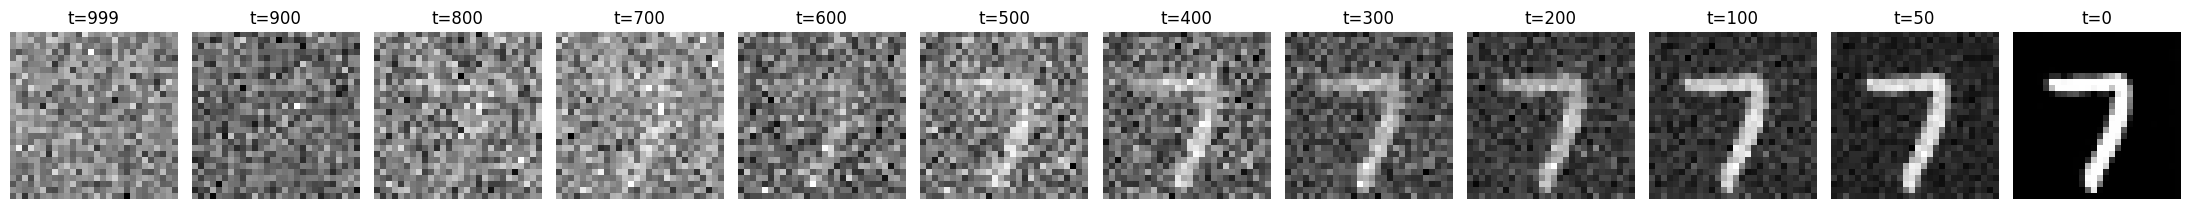

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    len(snapshots),
    figsize=(22,4)
)

for ax, (t, img) in zip(
    axes,
    snapshots
):

    ax.imshow(
        img[0,0],
        cmap="gray"
    )

    ax.set_title(
        f"t={t}"
    )

    ax.axis("off")

plt.tight_layout()

plt.show()

nice!

### GIF

GIF saved: reverse_diffusion.gif


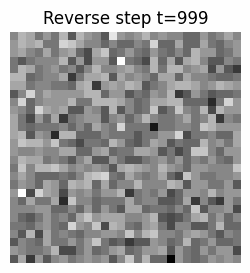

In [ ]:
import matplotlib.pyplot as plt

frame_paths = []

for i, (t, img) in enumerate(
    snapshots
):

    plt.figure(figsize=(3,3))

    plt.imshow(
        img[0,0],
        cmap="gray"
    )

    plt.title(
        f"Reverse step t={t}"
    )

    plt.axis("off")

    path = (
        f"reverse_frames/frame_{i:03d}.png"
    )

    plt.savefig(
        path,
        bbox_inches="tight"
    )

    plt.close()

    frame_paths.append(path)





import imageio.v2 as imageio

gif_path = (
    "reverse_diffusion.gif"
)

with imageio.get_writer(
    gif_path,
    mode="I",
    duration=0.5
) as writer:

    for path in frame_paths:

        image = imageio.imread(path)

        writer.append_data(image)

print(
    "GIF saved:",
    gif_path
)
# Display GIF in notebook
display(Image(open(gif_path,'rb').read()))

### **5. Comparison of Generator Performance Over Different Epochs**

### Comparison over different epochs

In [ ]:
# Defines a function to generate images from a given model checkpoint
def generate_from_checkpoint(
    checkpoint_path, # Path to the model checkpoint file
    batch_size=16    # Number of images to generate in a single batch
):

    # Initialize the U-Net model with predefined dimensions and settings
    model = Unet(
        dim=DIM,
        dim_mults=DIM_MULTS,
        channels=1,
        flash_attn=False
    )

    # Load the trained weights into the U-Net model from the specified checkpoint
    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device # Load the model to the appropriate device (CPU/GPU)
        )
    )

    model = model.to(device) # Move the model to the selected device

    # Wrap the loaded U-Net model with the GaussianDiffusion wrapper for sampling
    diffusion = GaussianDiffusion(
        model,
        image_size=IMAGE_SIZE,
        timesteps=TIME_STEPS,
        sampling_timesteps=SAMPLING_TIMESTEPS
    ).to(device)

    model.eval() # Set the model to evaluation mode (disables dropout, batchnorm updates, etc.)

    # Generate samples without tracking gradients (inference mode)
    with torch.no_grad():

        samples = diffusion.sample(
            batch_size=batch_size
        )

    return samples.cpu() # Return the generated samples on the CPU

# List of checkpoint file names to be evaluated
checkpoints = [
    "mnist_diffusion_epoch_10.pth",
    "mnist_diffusion_epoch_20.pth",
    "mnist_diffusion_epoch_30.pth",
    "mnist_diffusion_epoch_40.pth",
    "mnist_diffusion_epoch_50.pth"
]


In [36]:
# Initialize an empty list to store generated samples from all checkpoints
all_samples = []

# Iterate through each checkpoint path defined in the 'checkpoints' list
for ckpt in checkpoints:

    # Generate a batch of 5 samples using the model loaded from the current checkpoint
    samples = generate_from_checkpoint(
        ckpt,
        batch_size=5
    )

    # Append the generated samples for the current checkpoint to the 'all_samples' list
    all_samples.append(samples)

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

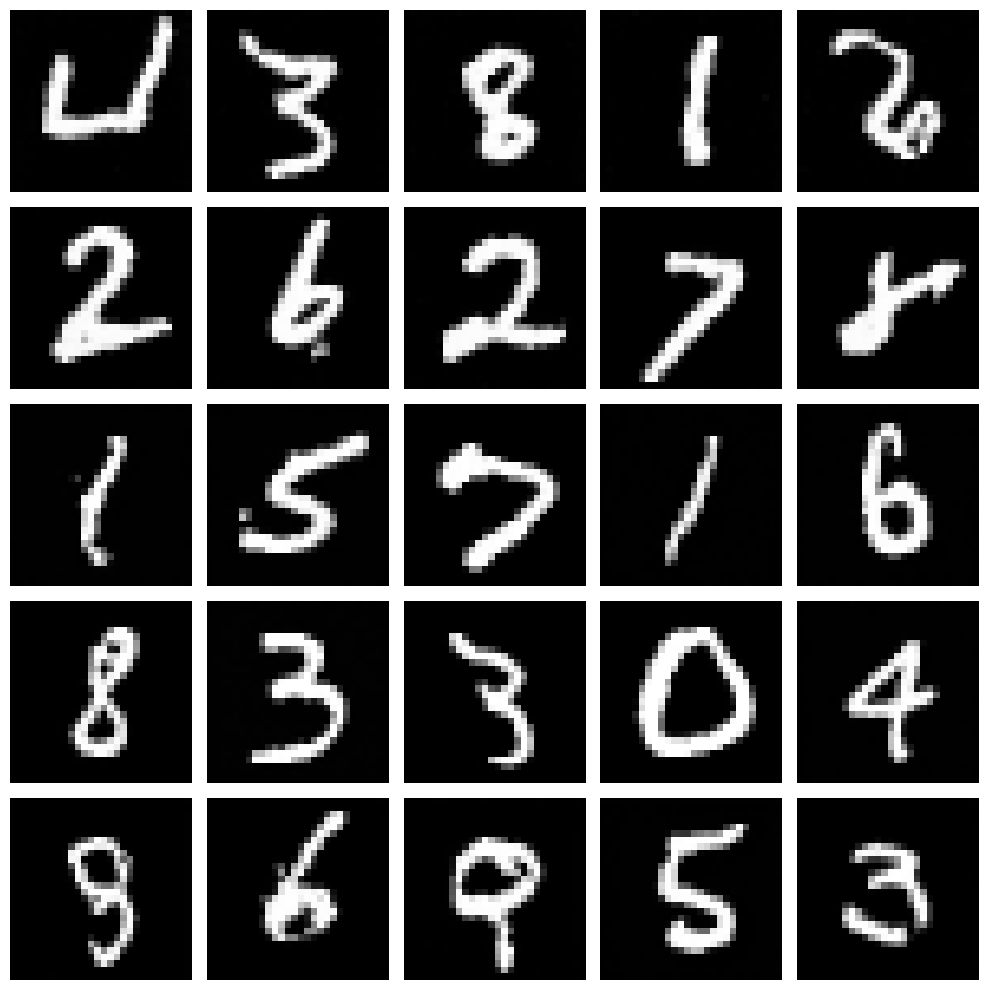

In [37]:
# Create a figure and a grid of subplots to display generated samples from different epochs.
# The number of rows is equal to the number of checkpoints, and there are 5 columns for 5 samples per epoch.
fig, axes = plt.subplots(
    len(checkpoints),
    5,
    figsize=(10,10) # Set the overall figure size
)

# Iterate through each checkpoint and its corresponding generated samples
for row, (ckpt, samples) in enumerate(
    zip(checkpoints, all_samples)
):

    # Extract the epoch number from the checkpoint filename
    epoch = ckpt.split("_")[-1].replace(".pth","")

    # Iterate through the 5 generated samples for the current epoch
    for col in range(5):

        # Display the image in the current subplot
        axes[row,col].imshow(
            samples[col,0],
            cmap="gray" # Use a grayscale colormap
        )

        # Turn off the axis ticks and labels for cleaner visualization
        axes[row,col].axis("off")

        # For the first column, set the y-axis label to indicate the epoch
        if col == 0:

            axes[row,col].set_ylabel(
                f"Epoch {epoch}",
                fontsize=12
            )

# Adjust subplot parameters for a tight layout
plt.tight_layout()

# Display the figure with all generated samples
plt.show()

Above grid plot corresponds to image generation for each checkpoint (epoch). Here, each row corresponds to a different checkpoint(epoch). Apparentl, checkpoint 3, 4 and 5 contains better quality digits than 1 and 2 checkpoint. The digits are cleaner, better quality, complete and recognizable. Furthur inspection would be done by FID score.

### Fréchet Inception Distance (FID)

In practice, FID can be interpreted as a statistical distance between the distribution of generated images and the distribution of real images in a learned feature space. Therefore, decreasing FID values during training indicate that the diffusion model is progressively learning a representation that more closely matches the true MNIST data distribution.

To evaluate generative performance more directly, the Fréchet Inception Distance (FID) was used. FID compares statistical properties of generated images with those of real images by computing the distance between feature distributions extracted from a pretrained neural network. Unlike the training loss, FID evaluates the final generated samples themselves and therefore provides a more meaningful measure of generation quality. A lower FID score indicates that the generated images are more similar to the real dataset, while a higher score suggests a larger discrepancy between the generated and real distributions. An ideal model would achieve an FID of 0, corresponding to identical feature distributions.

For the MNIST dataset, FID values should be interpreted as relative indicators rather than absolute measures, since the metric was originally designed for more complex natural-image datasets. Nevertheless, some general guidelines can still be used. FID values above roughly 50 usually indicate poor generation quality, values between 20 and 50 indicate that the model has learned significant structure from the data but still produces noticeable imperfections, while values below 20 are generally considered good. Values approaching 10 or below correspond to very realistic and diverse generations that closely match the real data distribution.

### Install FID package

In [ ]:
pip install pytorch-fid

### Create folders

In [38]:
import os
import torchvision

import os

os.makedirs(
    "real_images",
    exist_ok=True
)

os.makedirs(
    "generated_images",
    exist_ok=True
)

### Save real MNIST images

In [39]:
import torchvision

n_real = 1000

count = 0

for images, _ in loader:

    for image in images:

        torchvision.utils.save_image(
            image,
            f"real_images/{count:05d}.png"
        )

        count += 1

        if count >= n_real:
            break

    if count >= n_real:
        break

print(
    f"Saved {count} real images"
)

Saved 1000 real images


### generate 1000 sample digit images from Epoch 50_model

In [40]:
n_generated = 1000
batch_size = 100

count = 0

while count < n_generated:

    current_batch = min(
        batch_size,
        n_generated - count
    )

    with torch.no_grad():

        samples = diffusion.sample(
            batch_size=current_batch
        )

    samples = samples.cpu()

    for i in range(current_batch):

        torchvision.utils.save_image(
            samples[i],
            f"generated_images/{count+i:05d}.png"
        )

    count += current_batch

    print(
        f"{count}/{n_generated}"
    )

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

100/1000


sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

200/1000


sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

...

800/1000


sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

900/1000


sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

1000/1000


### Evaluate FID score

In [41]:
!python -m pytorch_fid real_images generated_images

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100% 91.2M/91.2M [00:00<00:00, 107MB/s]
100% 20/20 [00:04<00:00,  4.28it/s]
100% 20/20 [00:04<00:00,  4.81it/s]
FID:  15.258416783566219


The Fréchet Inception Distance (FID) between 1000 generated images and 1000 real MNIST images is 15.26. Since lower FID values indicate a closer match between generated and real data distributions, this result suggests that the DDPM successfully learned the structure of handwritten digits and generated realistic samples.

Combined with visual inspection of the generated samples for Epoch_50 Generator, this suggests that the diffusion model has learned a meaningful representation of the handwritten digit distribution and can synthesize realistic digits from pure Gaussian noise

### Comparison of FID at Five checkpoints

In [42]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt

# Import the FID calculation function
from pytorch_fid.fid_score import (
    calculate_fid_given_paths
)

# Import the U-Net model and Gaussian Diffusion wrapper
from denoising_diffusion_pytorch import (
    Unet,
    GaussianDiffusion
)

# Define the epochs for which checkpoints are available
epochs = [10, 20, 30, 40, 50]

# Model and image parameters (re-defined for clarity in this cell)
DIM = 32
DIM_MULTS = (1, 2, 4)

IMAGE_SIZE = 28
TIME_STEPS = 1000
SAMPLING_TIMESTEPS = 250

N_IMAGES = 1000  # Number of images to generate for FID calculation
GEN_BATCH_SIZE = 100  # Batch size for image generation

# Determine the device to run the model on (GPU if available, else CPU)
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

# List to store FID scores for each epoch
fid_scores = []

# Iterate through each epoch to evaluate the corresponding checkpoint
for epoch in epochs:

    print(f"\nEvaluating Epoch {epoch}")


    # Initialize and load the U-Net model from the saved checkpoint


    model = Unet(
        dim=DIM,
        dim_mults=DIM_MULTS,
        channels=1,
        flash_attn=False
    )

    model.load_state_dict(
        torch.load(
            f"mnist_diffusion_epoch_{epoch}.pth",
            map_location=device
        )
    )

    model = model.to(device) # Move model to the selected device
    model.eval() # Set model to evaluation mode

    # Initialize the Gaussian Diffusion wrapper with the loaded model
    diffusion = GaussianDiffusion(
        model,
        image_size=IMAGE_SIZE,
        timesteps=TIME_STEPS,
        sampling_timesteps=SAMPLING_TIMESTEPS
    ).to(device)


    # Create a directory to save generated images for the current epoch


    output_dir = f"generated_epoch_{epoch}"

    os.makedirs(
        output_dir,
        exist_ok=True
    )


    # Generate a specified number of images


    count = 0

    while count < N_IMAGES:

        current_batch = min(
            GEN_BATCH_SIZE,
            N_IMAGES - count
        )

        # Generate samples without tracking gradients (inference mode)
        with torch.no_grad():

            samples = diffusion.sample(
                batch_size=current_batch
            )

        samples = samples.cpu() # Move generated samples to CPU

        # Save each generated image to the output directory
        for i in range(current_batch):

            torchvision.utils.save_image(
                samples[i],
                f"{output_dir}/{count+i:05d}.png"
            )

        count += current_batch

        print(
            f"Generated {count}/{N_IMAGES}",
            end="\r"
        )


    # Compute the FID score between real and generated images


    fid = calculate_fid_given_paths(
        [
            "real_images", # Path to real images
            output_dir     # Path to generated images
        ],
        batch_size=50,
        device=device,
        dims=2048 # Dimension of Inception features to use
    )

    fid_scores.append(fid) # Store the computed FID score

    print(
        f"\nEpoch {epoch}: "
        f"FID = {fid:.3f}"
    )

# Print the final FID results for all evaluated epochs
print("\nFinal Results")

for epoch, fid in zip(
    epochs,
    fid_scores
):

    print(
        f"Epoch {epoch:3d} "
        f"-> FID {fid:.3f}"
    )



Evaluating Epoch 10


sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

...

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:04<00:00,  4.64it/s]



Epoch 50: FID = 15.905

Final Results
Epoch  10 -> FID 21.469
Epoch  20 -> FID 17.988
Epoch  30 -> FID 15.759
Epoch  40 -> FID 16.536
Epoch  50 -> FID 15.905


### Plot FID over 5 epochs checkpoints

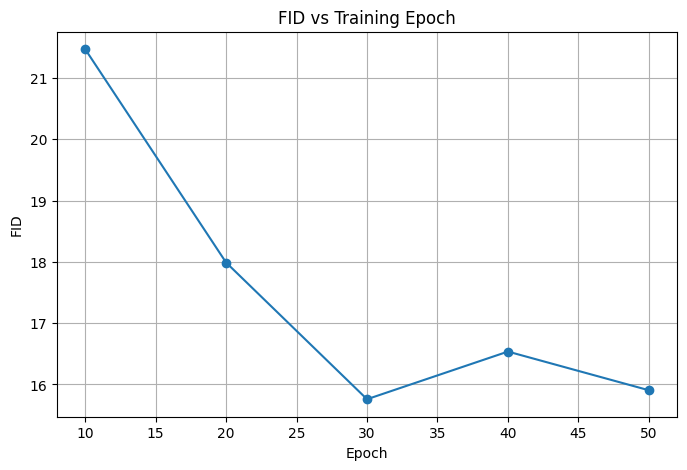

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    fid_scores,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("FID")

plt.title(
    "FID vs Training Epoch"
)

plt.grid()

plt.show()

The FID scores decreased rapidly during the early stages of training, indicating that the diffusion model was progressively learning the underlying structure of handwritten digits. The best checkpoint among the saved epochs was obtained at epoch 30 with an FID score of 15.759, while later checkpoints achieved similar but not substantially better values. This suggests that the model had already learned most of the relevant features of the MNIST distribution by epoch 30 and that additional training yielded diminishing returns. The observation that the lowest FID was not necessarily associated with the final training epoch highlights an important limitation of using the training loss alone to evaluate generative models. While the denoising loss continued to optimize the training objective, the perceptual quality and distributional similarity of the generated samples, as measured by FID, had largely converged.

### **6: Conclusions**

The Diffusion model had been effective approach to develop a MNIST Digit Generator. Convergence was acheived at fairly earlier epochs, which shows that the network effectively learned significant features/paramters earlier and saturation is acheived. Imporvement could be acheived via tuning the hyperparameters (learning rate, batch size, diffusion timesteps, or the number of training epochs). Additionally, significant improvement in model´s performance can be acheived by altering the model architecture itself. For example, using additional strategies to improve the training/learning capacity of the model.By enabling network learn slowly but effectively (regularization), only then additional epochs help, otherwise, it leads to overfitting. The U-Net architecture could be expanded by increasing its depth or number of channels, allowing the model to learn more complex image features.

Overall a best_model FIDscore of 15.759 shows a good diffusion model, with sufficient variation in generation, better quality and recognizability of the digits.


### Furthur methods that we can look forward to:





1. Using different noise schedules, such as cosine schedules, could be investigated to improve the forward and reverse diffusion processes.

2. Ttraining for a longer period while selecting the model based on the best FID score may lead to better sample quality.

3. Finally, techniques such as Exponential Moving Average (EMA) of the model weights and classifier-free guidance could be incorporated, as these methods have been shown to improve the stability and quality of diffusion model generation. These modifications could potentially reduce the FID score further and produce more realistic handwritten digits. Offcourse, in addition to hyper.parameter tuning and Unet model optimisation for the this specific problem.